In [1]:
# importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [2]:
# loading dataset

df = pd.read_csv("house.csv")

# first 5 rows

print(df.head())

      crim    zn  indus  chas    nox     rm   age     dis  rad  tax  ptratio  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        b  lstat  medv  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  


In [3]:
# dataset information

print(df.shape)

print(df.dtypes)

print(df.describe())

print(df.isnull().sum())

(506, 14)
crim       float64
zn         float64
indus      float64
chas         int64
nox        float64
rm         float64
age        float64
dis        float64
rad          int64
tax          int64
ptratio    float64
b          float64
lstat      float64
medv       float64
dtype: object
             crim          zn       indus        chas         nox          rm  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean     3.613524   11.363636   11.136779    0.069170    0.554695    6.284634   
std      8.601545   23.322453    6.860353    0.253994    0.115878    0.702617   
min      0.006320    0.000000    0.460000    0.000000    0.385000    3.561000   
25%      0.082045    0.000000    5.190000    0.000000    0.449000    5.885500   
50%      0.256510    0.000000    9.690000    0.000000    0.538000    6.208500   
75%      3.677083   12.500000   18.100000    0.000000    0.624000    6.623500   
max     88.976200  100.000000   27.740000    1.000000    0.871

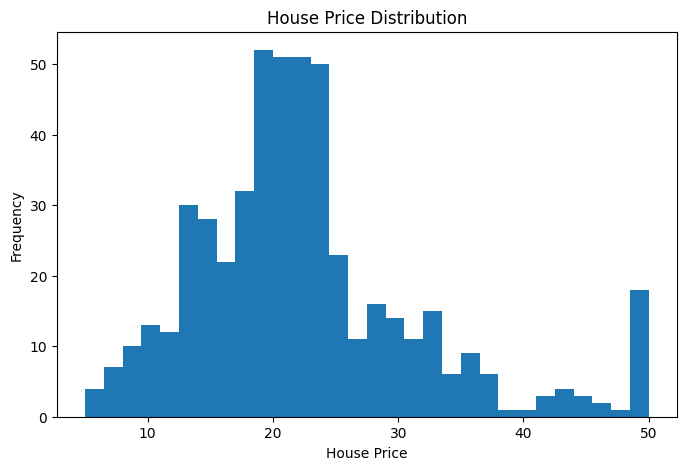

medv       1.000000
rm         0.695360
zn         0.360445
b          0.333461
dis        0.249929
chas       0.175260
age       -0.376955
rad       -0.381626
crim      -0.388305
nox       -0.427321
tax       -0.468536
indus     -0.483725
ptratio   -0.507787
lstat     -0.737663
Name: medv, dtype: float64


In [4]:
# plotting house price distribution

plt.figure(figsize=(8,5))

plt.hist(df['medv'], bins=30)

plt.title("House Price Distribution")

plt.xlabel("House Price")

plt.ylabel("Frequency")

plt.show()

# correlation with target column

correlation = df.corr()['medv'].sort_values(ascending=False)

print(correlation)

In [5]:
# selecting input and target columns

X = df.drop('medv', axis=1)

y = df['medv']

# feature scaling

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

# checking shapes

print(X_train.shape)

print(X_test.shape)


(404, 13)
(102, 13)


In [6]:
# linear regression model

lr = LinearRegression()

# training model

lr.fit(X_train, y_train)

# predictions

y_pred_lr = lr.predict(X_test)

# evaluation

mae = mean_absolute_error(y_test, y_pred_lr)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))

r2 = r2_score(y_test, y_pred_lr)

print("Linear Regression Results")

print("MAE:", mae)

print("RMSE:", rmse)

print("R2 Score:", r2)

Linear Regression Results
MAE: 3.1890919658878505
RMSE: 4.928602182665338
R2 Score: 0.6687594935356318


In [7]:
# ridge regression model

ridge = Ridge(alpha=1.0)

# training model

ridge.fit(X_train, y_train)

# predictions

y_pred_ridge = ridge.predict(X_test)

# evaluation

mae_ridge = mean_absolute_error(y_test, y_pred_ridge)

rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))

r2_ridge = r2_score(y_test, y_pred_ridge)

print("Ridge Regression Results")

print("MAE:", mae_ridge)

print("RMSE:", rmse_ridge)

print("R2 Score:", r2_ridge)

Ridge Regression Results
MAE: 3.185903499298025
RMSE: 4.9309773335472125
R2 Score: 0.6684401592810272


In [8]:
# random forest regressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# training model

rf.fit(X_train, y_train)

# predictions

y_pred_rf = rf.predict(X_test)

# evaluation

mae_rf = mean_absolute_error(y_test, y_pred_rf)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")

print("MAE:", mae_rf)

print("RMSE:", rmse_rf)

print("R2 Score:", r2_rf)

Random Forest Results
MAE: 2.047411764705882
RMSE: 2.8155186615139556
R2 Score: 0.891903226702447


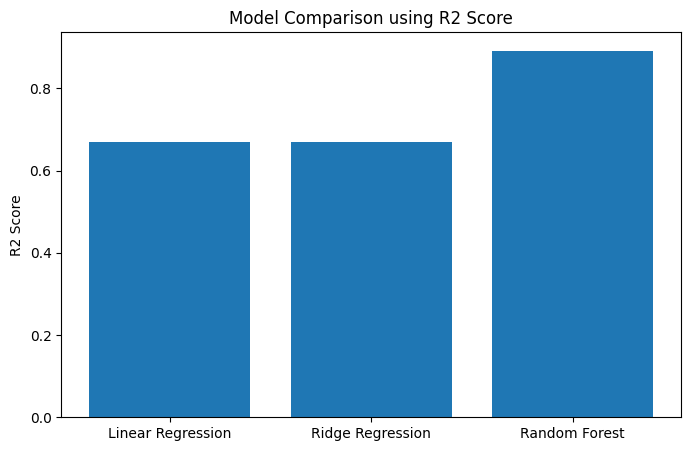

In [9]:
# comparing model R2 scores

models = [
    'Linear Regression',
    'Ridge Regression',
    'Random Forest'
]

scores = [
    r2,
    r2_ridge,
    r2_rf
]

plt.figure(figsize=(8,5))

plt.bar(models, scores)

plt.title("Model Comparison using R2 Score")

plt.ylabel("R2 Score")

plt.show()

# Conclusion

In this project, house price prediction was performed using different machine learning regression models.

The dataset was analyzed and preprocessed using descriptive statistics, feature selection, visualization, feature scaling, and train-test splitting.

Three regression models were trained and compared:

* Linear Regression
* Ridge Regression
* Random Forest Regressor

Among all models, Random Forest Regressor achieved the highest R2 score and lowest error values, making it the best-performing model for house price prediction.

The project helped in understanding:

* regression models
* feature selection
* feature scaling
* model evaluation
* regularization using Ridge Regression
* comparison of machine learning algorithms

This project also demonstrated how machine learning can be used to predict house prices based on housing-related features.
